In [27]:
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import hist
import hist.dask as hda
import dask
import coffea.processor as processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import vector
import json

NanoAODSchema.warn_missing_crossrefs = False

In [28]:
# Datasets:
#/BulkGravToWW_narrow_M-*_13TeV-madgraph/*NanoAODv7*/NANOAODSIM
#/RSGravToWWToWlepWhad_width0p1_M-*_TuneCUETP8M1_13TeV-madgraph-pythia8/*NanoAODv3*/NANOAODSIM


# When having a large number of files it is useful to put the list on a separate file.
# import json

# with open("semileptonic_notebooks/samples.json", 'r') as sample_file:
#     fileset = json.load(sample_file)

# for sample in fileset:
#     print(sample)

# For now we are only testing on a limited number of files so they are just listed here
fileset = {
    'BulkGravToWW': {
        'files': {
            # M-1000 sample
            'root://cmsxrootd.fnal.gov//store/mc/RunIISummer16NanoAODv7/BulkGravToWW_narrow_M-1000_13TeV-madgraph/NANOAODSIM/PUMoriond17_Nano02Apr2020_102X_mcRun2_asymptotic_v8-v1/100000/D4404DCB-FBF8-C640-87B0-2DA1D5139083.root': "Events",
        },
        'metadata': {
            'is_mc': True,
        },
    },
    'RSGravToWW': {
        'files': {
            'root://cmsxrootd.fnal.gov//store/mc/RunIISummer16NanoAODv3/RSGravToWWToWlepWhad_width0p1_M-1200_TuneCUETP8M1_13TeV-madgraph-pythia8/NANOAODSIM/PUMoriond17_94X_mcRun2_asymptotic_v3-v1/60000/4442437A-52BB-E811-A8DA-90E2BACC5EEC.root': "Events",
          },
        'metadata': {
            'is_mc': 'Events',
        },
    }
}

In [29]:
# This step takes some time because it is loading the events
test_dataset_bulk = 'BulkGravToWW'
events = NanoEventsFactory.from_root(
    fileset[test_dataset_bulk]['files'],
    entry_stop = 1000,
    metadata = fileset[test_dataset_bulk]['metadata'],
    schemaclass = NanoAODSchema,
    delayed=False,
).events()

# test_dataset_rs = 'RSGravToWW'
# events = NanoEventsFactory.from_root(
#     fileset[test_dataset_rs]['files'],
#     entry_stop =1000,
#     metadata = fileset[test_dataset_rs]['metadata'],
#     schemaclass = NanoAODSchema,
#     delayed = False,
# ).events()

### Selecting interesting events

We will need to discuss what does it mean. For instance it could be events where both W decay to quarks to enhance our NN training sample, events where one W decays to leptons and one to quarks that more similar to what we will have in our final analysis. One could also select events where both Ws decay to leptons to compare with previous studies...

### TASK 1:
Lets refresh what is insiede an event

In [30]:
events.fields

['btagWeight',
 'CaloMET',
 'genTtbarId',
 'Pileup',
 'SoftActivityJetHT10',
 'GenVisTau',
 'SubGenJetAK8',
 'fixedGridRhoFastjetCentralCalo',
 'SoftActivityJetHT',
 'ChsMET',
 'PuppiMET',
 'SoftActivityJetHT2',
 'OtherPV',
 'LHEReweightingWeight',
 'fixedGridRhoFastjetCentralNeutral',
 'L1simulation',
 'IsoTrack',
 'RawMET',
 'fixedGridRhoFastjetCentral',
 'HTXS',
 'GenDressedLepton',
 'SoftActivityJetNjets10',
 'RawPuppiMET',
 'Tau',
 'FsrPhoton',
 'SoftActivityJetHT5',
 'HLT',
 'LHEPart',
 'fixedGridRhoFastjetAll',
 'LHEPdfWeight',
 'SV',
 'FatJet',
 'fixedGridRhoFastjetCentralChargedPileUp',
 'SoftActivityJetNjets5',
 'HLTriggerFinalPath',
 'L1PreFiringWeight',
 'TkMET',
 'PV',
 'CorrT1METJet',
 'GenIsolatedPhoton',
 'run',
 'Electron',
 'HLTriggerFirstPath',
 'MET',
 'TrigObj',
 'GenPart',
 'SoftActivityJet',
 'genWeight',
 'L1',
 'Flag',
 'PSWeight',
 'Photon',
 'GenMET',
 'SubJet',
 'event',
 'LHE',
 'Muon',
 'Generator',
 'SoftActivityJetNjets2',
 'GenJet',
 'Jet',
 'GenJetAK8'

### TASK 2:

You should already be familiar with some of the fields but you can try to understand more here https://cms-nanoaod-integration.web.cern.ch/.

The link above is very technical and used by experienced analyzers so I do not expect you to learn or understand everything in it (I also do not know all!!)

### TASK 3:

Let's apply basic selections on Muons and Electrons. Understand what the selections mean. You can have a better idea of their effect if you plot some variables as the pt or if you print the number of electrons/muons in the event. Or how many events are passing the selections.

241 out of 724 muons pass the tight selection


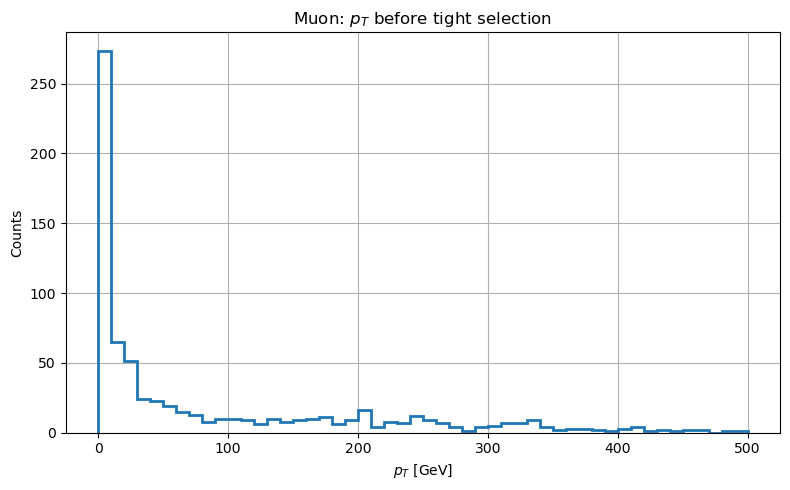

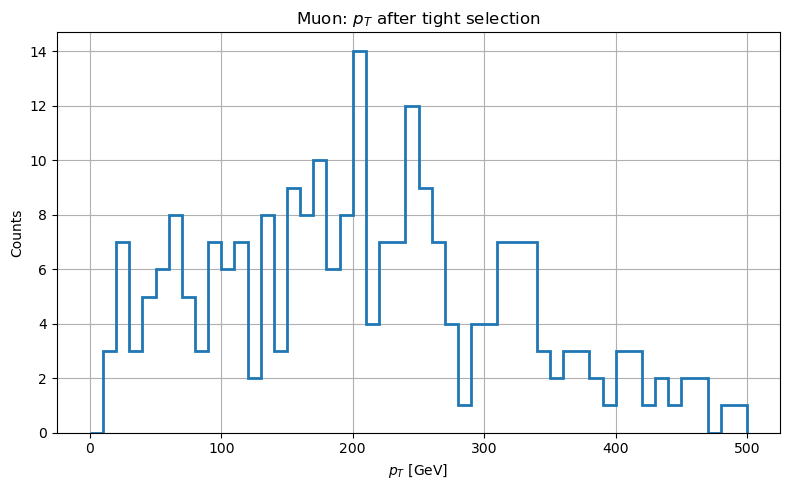

In [31]:
muons = events.Muon
electrons = events.Electron

# Muon Tight selection
muons_tight = muons[
    (muons.pt > 10) &
    (np.abs(muons.eta) < 2.4) &
    (muons.tightId) &
    (
        ((muons.pt < 20) & (np.abs(muons.dxy) < 0.01)) |
        ((muons.pt >= 20) & (np.abs(muons.dxy) < 0.02))
    ) &
    (np.abs(muons.dz) < 0.1) &
    # particle flow isolated: tight or greater
    (muons.pfIsoId >= 4)
]

print(len(ak.flatten(muons_tight)), 'out of' ,len(ak.flatten(muons)), 'muons pass the tight selection')

plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(muons.pt)), bins=50, range=(0, 500), histtype='step', linewidth=2)
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Muon: $p_T$ before tight selection")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(muons_tight.pt)), bins=50, range=(0, 500), histtype='step', linewidth=2)
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Muon: $p_T$ after tight selection")
plt.grid(True)
plt.tight_layout()
plt.show()

### TASK 4:

Try to add similar selections for the electrons as well



229 out of 897 electrons pass the tight selection


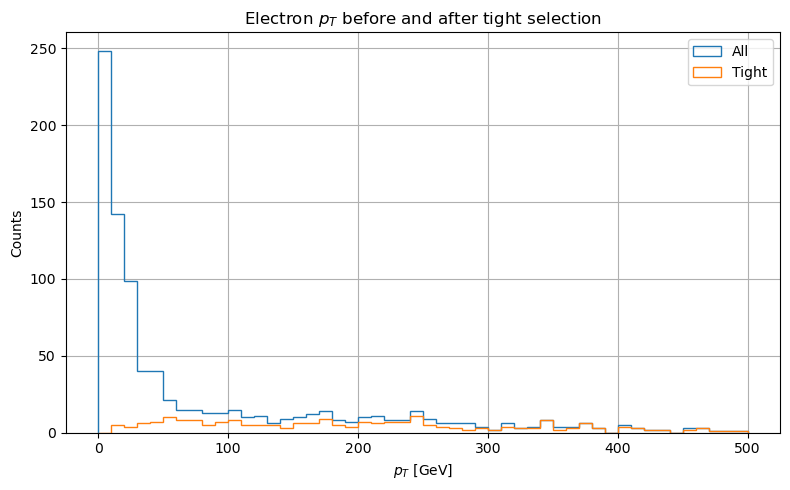

In [32]:
# Electron Tight selection

electrons_tight = electrons[
    (electrons.pt > 10) &
    (np.abs(electrons.eta) < 2.4) &  # barrel + endcap
    # (electrons.mvaFall17V2Iso_WP90 == True) &
    # (electrons.cutBased >= 1) &      # tight cut-based ID
    (np.abs(electrons.dxy) < 0.05) & # dxy tighter
    (np.abs(electrons.dz) < 0.1) &
    (electrons.pfRelIso03_all < 0.15) &  # isolated
    (electrons.lostHits <= 1) &
    (electrons.convVeto == True)
]

print(len(ak.flatten(electrons_tight)), 'out of' ,len(ak.flatten(electrons)), 'electrons pass the tight selection')

plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(electrons.pt)), bins=50, range=(0, 500), histtype='step', label='All')
plt.hist(ak.to_numpy(ak.flatten(electrons_tight.pt)), bins=50, range=(0, 500), histtype='step', label='Tight')
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Electron $p_T$ before and after tight selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



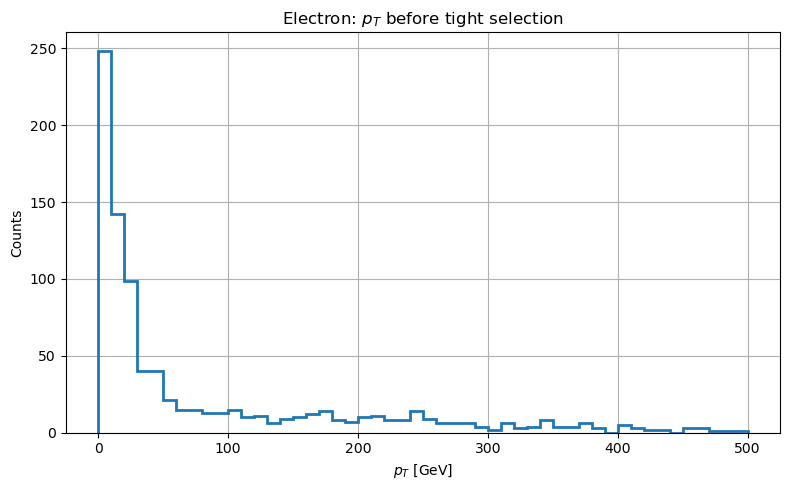

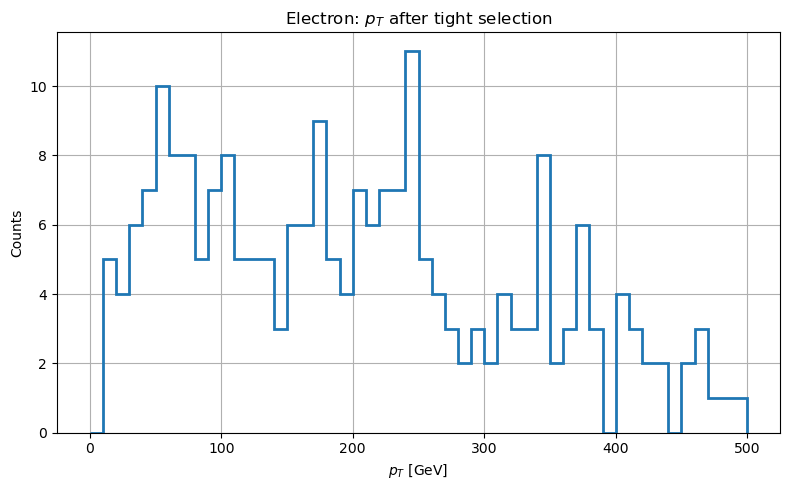

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(electrons.pt)), bins=50, range=(0, 500), histtype='step', linewidth=2)
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Electron: $p_T$ before tight selection")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(electrons_tight.pt)), bins=50, range=(0, 500), histtype='step', linewidth=2)
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Electron: $p_T$ after tight selection")
plt.grid(True)
plt.tight_layout()
plt.show()

### TASK 5: 

Now require to have exactly one tightly identified electron or muon
and apply the following thresholds
```
electron_pt_threshold = 35
muon_pt_threshold = 30
pt_miss_threshold = 30
```

In [34]:
# Thresholds
electron_pt_threshold = 35
muon_pt_threshold = 30
pt_miss_threshold = 30

# Tight leptons (using previous selections)
tight_muons = muons_tight[muons_tight.pt > muon_pt_threshold]
tight_electrons = electrons_tight[electrons_tight.pt > electron_pt_threshold]

# Count of tight leptons
tight_muon_count = ak.num(tight_muons)
tight_electron_count = ak.num(tight_electrons)

# --- Loose leptons for vetoing ---
loose_muons = muons[muons.looseId]
loose_muons = loose_muons[loose_muons.pt > 10]

loose_electrons = electrons[electrons.cutBased >= 2]
loose_electrons = loose_electrons[loose_electrons.pt > 10]

# Count of loose leptons
loose_lepton_count = ak.num(loose_muons) + ak.num(loose_electrons)

# --- Event selection mask: exactly one tight lepton and no extra loose leptons ---
single_lepton_mask = ((tight_muon_count + tight_electron_count) == 1) & (loose_lepton_count == 1)

# Apply mask to get final event selection
events_selected = events[single_lepton_mask]

print(f"{len(events_selected)} events passed the tight lepton selection and loose veto.")

312 events passed the tight lepton selection and loose veto.


In [35]:
# Masks for exactly one tight lepton
one_tight_electron_mask = (tight_electron_count == 1) & (tight_muon_count == 0) & (loose_lepton_count == 1)
one_tight_muon_mask = (tight_muon_count == 1) & (tight_electron_count == 0) & (loose_lepton_count == 1)

# Apply masks to original tight collections
tight_electron_one = tight_electrons[one_tight_electron_mask]
tight_muon_one = tight_muons[one_tight_muon_mask]


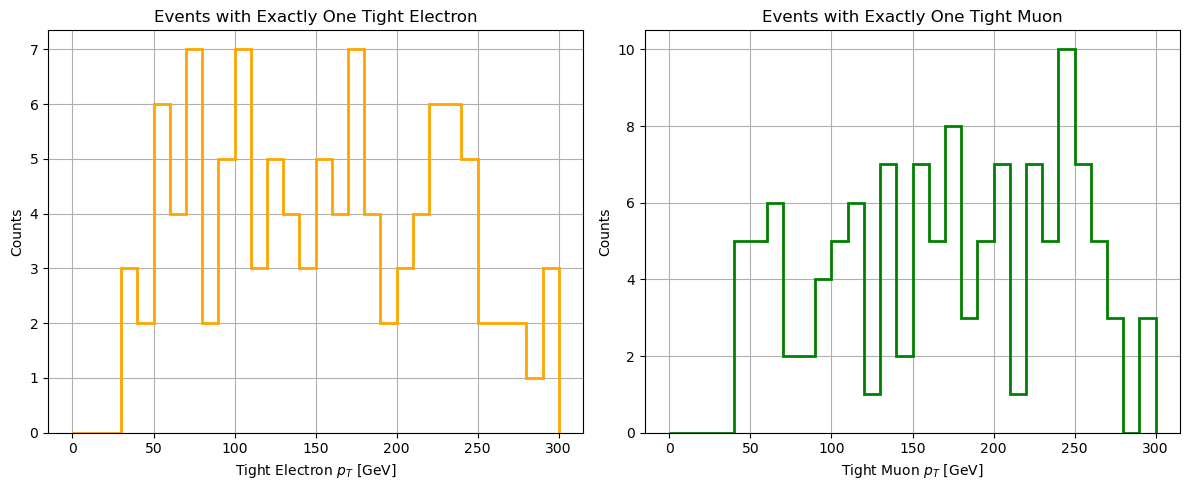

In [36]:
plt.figure(figsize=(12, 5))

# --- Electrons ---
plt.subplot(1, 2, 1)
plt.hist(ak.to_numpy(ak.flatten(tight_electron_one.pt)), bins=30, range=(0, 300), histtype='step', linewidth=2, color='orange')
plt.xlabel(r"Tight Electron $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Events with Exactly One Tight Electron")
plt.grid(True)

# --- Muons ---
plt.subplot(1, 2, 2)
plt.hist(ak.to_numpy(ak.flatten(tight_muon_one.pt)), bins=30, range=(0, 300), histtype='step', linewidth=2, color='green')
plt.xlabel(r"Tight Muon $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Events with Exactly One Tight Muon")
plt.grid(True)

plt.tight_layout()
plt.show()

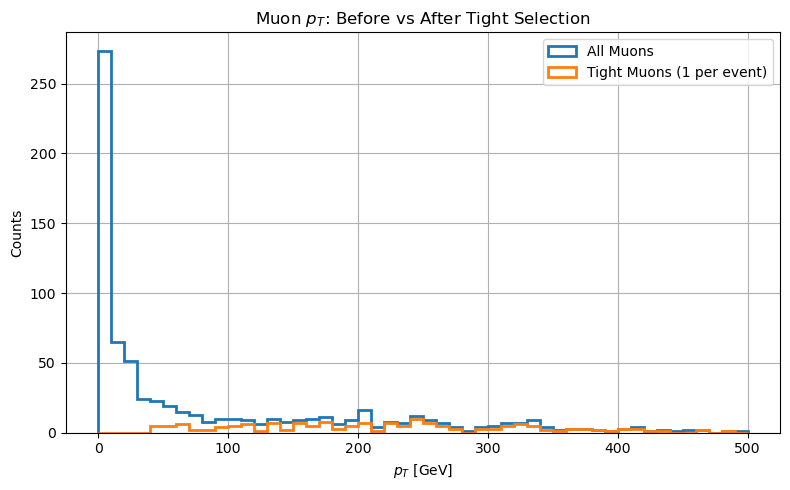

In [37]:
plt.figure(figsize=(8, 5))

# Before selection
plt.hist(ak.to_numpy(ak.flatten(muons.pt)), bins=50, range=(0, 500), 
         histtype='step', linewidth=2, label='All Muons')

# After tight selection and exactly one
plt.hist(ak.to_numpy(ak.flatten(tight_muon_one.pt)), bins=50, range=(0, 500), 
         histtype='step', linewidth=2, label='Tight Muons (1 per event)')

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Muon $p_T$: Before vs After Tight Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

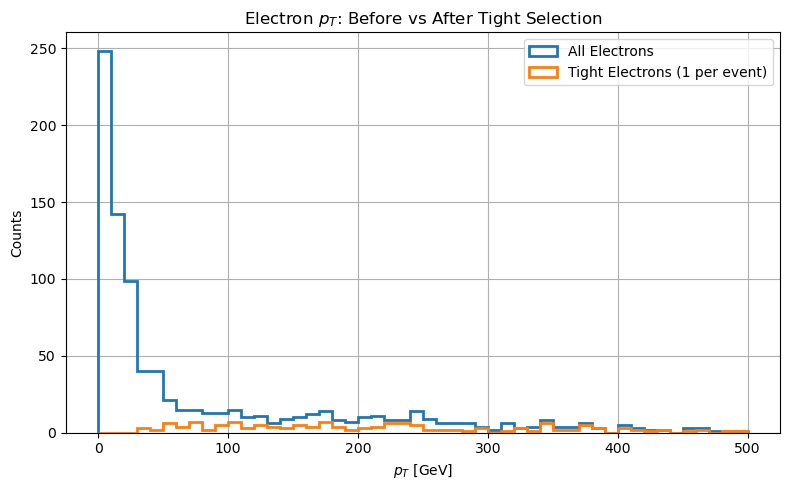

In [38]:
plt.figure(figsize=(8, 5))

# Before selection
plt.hist(ak.to_numpy(ak.flatten(electrons.pt)), bins=50, range=(0, 500), 
         histtype='step', linewidth=2, label='All Electrons')

# After tight selection and exactly one
plt.hist(ak.to_numpy(ak.flatten(tight_electron_one.pt)), bins=50, range=(0, 500), 
         histtype='step', linewidth=2, label='Tight Electrons (1 per event)')

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Electron $p_T$: Before vs After Tight Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
# # Here are also some looser selections 
# # You can play plotting variables for tight and loose identified leptons, 
# # but it is not required...... 
# loose_muons = muons[muons.looseId]
# loose_muon_count = ak.num(loose_muons[loose_muons.pt > 10])

# loose_electrons = electrons[(electrons.cutBased >= 2)]
# loose_electron_count = ak.num(loose_electrons[loose_electrons.pt > 10])

# # Mask for vetoing extra loose leptons
# loose_lepton_veto_mask = (loose_muon_count + loose_electron_count) == 1

## We are mostly interested in Jets! 

### TASK 6:

Check the selections applied below on the jets. As before it is useful to plot some distributions like the jet mass or the momentum before and after applying the selections to check their effect and see how many events or jets pass a certain selection.

In [40]:
# FatJets cuts
clean_fatJets = events.FatJet[(events.FatJet.pt > 200) & (np.abs(events.FatJet.eta) < 2.4)]

#Jets cuts
clean_Jets = events.Jet[(events.Jet.pt > 30) & (np.abs(events.Jet.eta) < 4.7)]

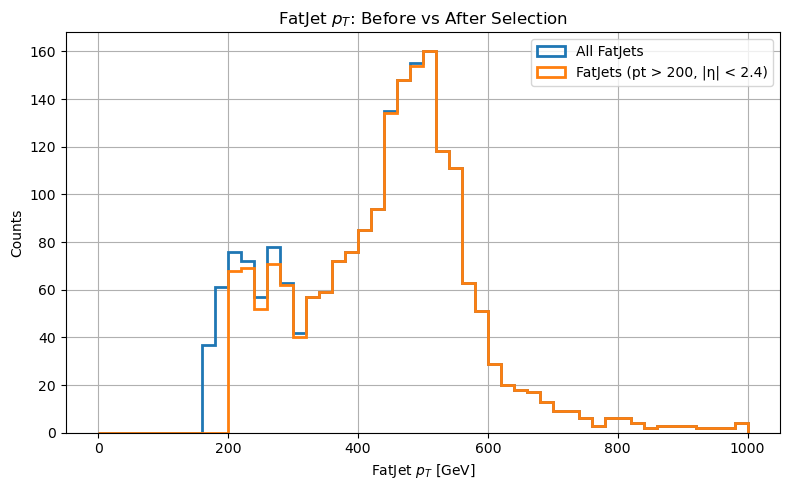

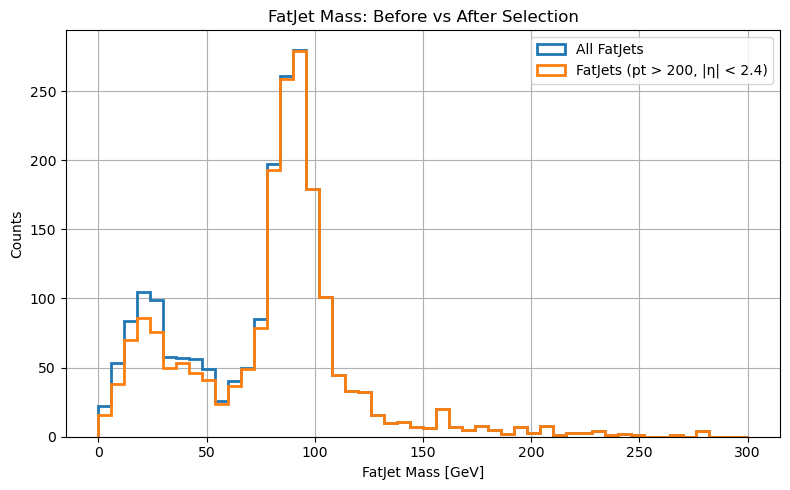

In [41]:
# --- FatJet pT ---
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(events.FatJet.pt)), bins=50, range=(0, 1000),
         histtype='step', linewidth=2, label='All FatJets')
plt.hist(ak.to_numpy(ak.flatten(clean_fatJets.pt)), bins=50, range=(0, 1000),
         histtype='step', linewidth=2, label='FatJets (pt > 200, |η| < 2.4)')
plt.xlabel(r"FatJet $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("FatJet $p_T$: Before vs After Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- FatJet mass ---
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(events.FatJet.mass)), bins=50, range=(0, 300),
         histtype='step', linewidth=2, label='All FatJets')
plt.hist(ak.to_numpy(ak.flatten(clean_fatJets.mass)), bins=50, range=(0, 300),
         histtype='step', linewidth=2, label='FatJets (pt > 200, |η| < 2.4)')
plt.xlabel(r"FatJet Mass [GeV]")
plt.ylabel("Counts")
plt.title("FatJet Mass: Before vs After Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\e'
<>:23: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_338/1008345665.py:23: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Jet $\eta$: Before vs After Selection")


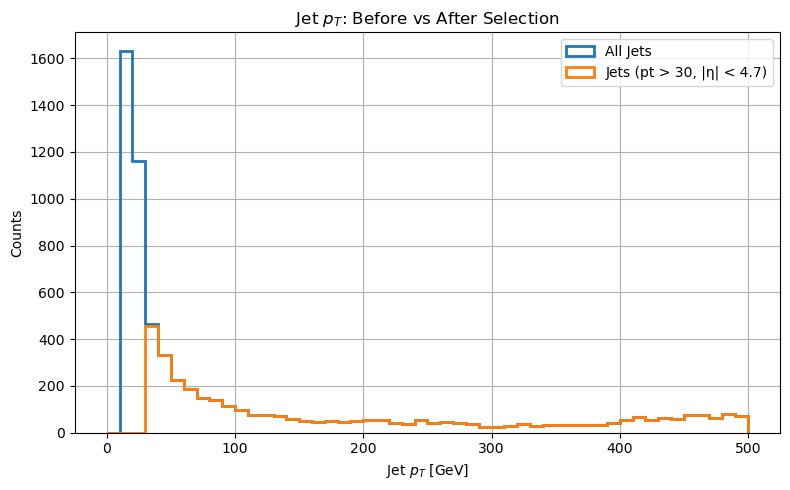

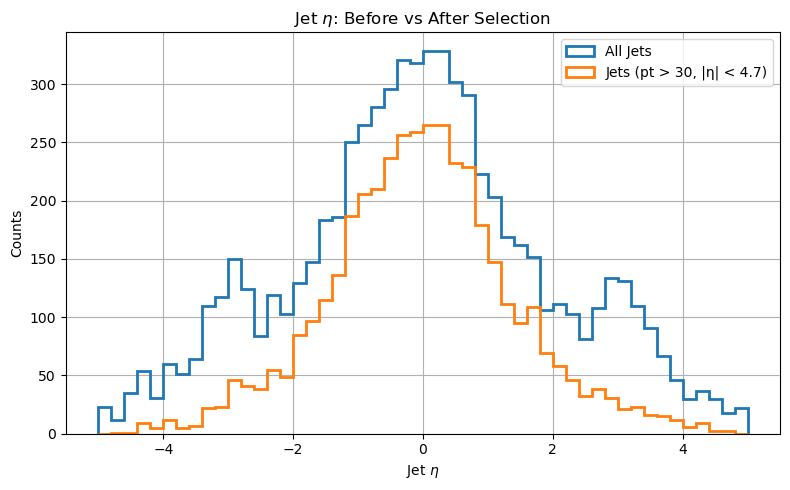

In [42]:
# --- Jet pT ---
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(events.Jet.pt)), bins=50, range=(0, 500),
         histtype='step', linewidth=2, label='All Jets')
plt.hist(ak.to_numpy(ak.flatten(clean_Jets.pt)), bins=50, range=(0, 500),
         histtype='step', linewidth=2, label='Jets (pt > 30, |η| < 4.7)')
plt.xlabel(r"Jet $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Jet $p_T$: Before vs After Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Jet eta ---
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(events.Jet.eta)), bins=50, range=(-5, 5),
         histtype='step', linewidth=2, label='All Jets')
plt.hist(ak.to_numpy(ak.flatten(clean_Jets.eta)), bins=50, range=(-5, 5),
         histtype='step', linewidth=2, label='Jets (pt > 30, |η| < 4.7)')
plt.xlabel(r"Jet $\eta$")
plt.ylabel("Counts")
plt.title("Jet $\eta$: Before vs After Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### TASK 7:

To avoid double counting we need to remove Jets overlapping with FatJets. Check how this is done below.

In [43]:
#Removing AK4(Jet) jets overlapping with AK8(FatJets) jets
# Get all combinations of jets and fatjets in every event
#--- Step 1: Form all possible Jet–FatJet pairs per event
jets_fatjets = ak.cartesian({"x": clean_Jets, "y": clean_fatJets})
# Check that jets satisfy the isolation 
# --- Step 2: Compute ΔR² separation between each Jet–FatJet pair
jets_iso_f = ((jets_fatjets["x"].eta-jets_fatjets["y"].eta)**2+(jets_fatjets["x"].phi-jets_fatjets["y"].phi)**2>0.8**2)
# Mask the jets_fatjets with the jets_iso_f to get jets isolated from fatjets
# --- Step 3: Mask out jets with ΔR < 0.8 (i.e. remove overlapping jets)
jets_fatjets = jets_fatjets[jets_iso_f]
# Separate pairs into jets and fatjets, redefining the jets (but not the fatjets) 
# --- Step 4: Unpack the surviving jets (no need to redefine the fatjets)
jets, fj = ak.unzip(jets_fatjets)

### TASK 8:

1) Can you add below the initial FatJet pt distribution? and see how it is changed after applying all selections
2) Can you plot the second leading jet?

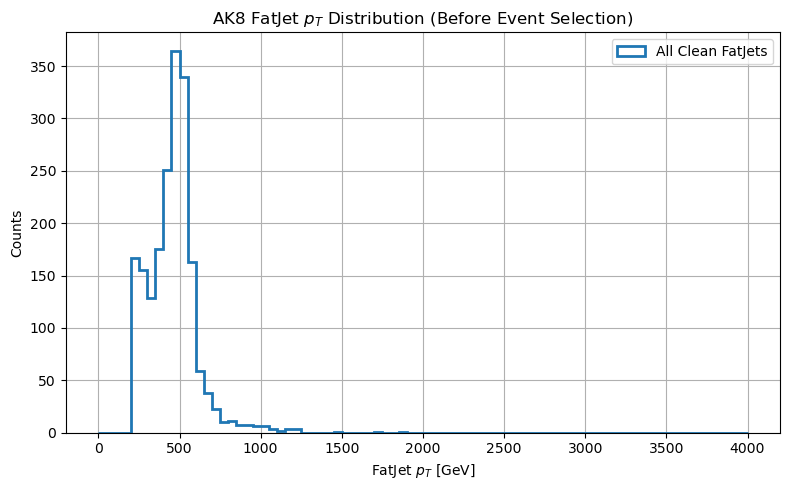

In [44]:
# Plot distribution of AK8 FatJets before applying AK8jets_candidates_mask
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(clean_fatJets.pt)), bins=80, range=(0, 4000),
         histtype='step', linewidth=2, label='All Clean FatJets')
plt.xlabel(r"FatJet $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("AK8 FatJet $p_T$ Distribution (Before Event Selection)")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fc06ab4bf80>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

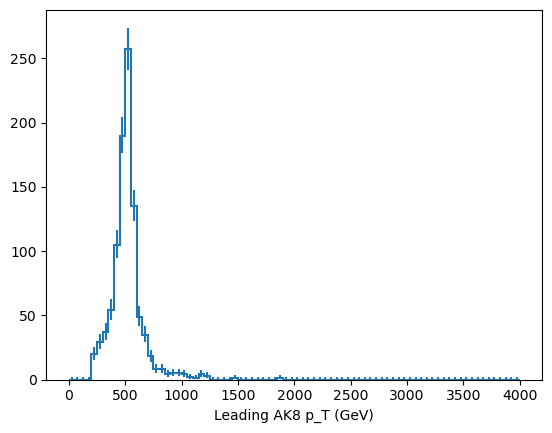

In [45]:
AK8jets_candidates_mask = ak.num(clean_fatJets) >= 1
Wjets_candidates = clean_fatJets[AK8jets_candidates_mask]

leading_W_jet = Wjets_candidates[:, 0]
leading_W_jet_pt = leading_W_jet.pt

leading_W_pt_hist = hist.Hist(hist.axis.StrCategory(name='dataset', label="Dataset", categories=[], growth=True),
                            hist.axis.Regular(name='leading_AK8_pt', label='Leading AK8 p_T (GeV)', bins=80, start=0, stop=4000))
leading_W_pt_hist.fill(dataset=test_dataset_bulk, leading_AK8_pt=leading_W_jet_pt)
leading_W_pt_hist.plot1d()

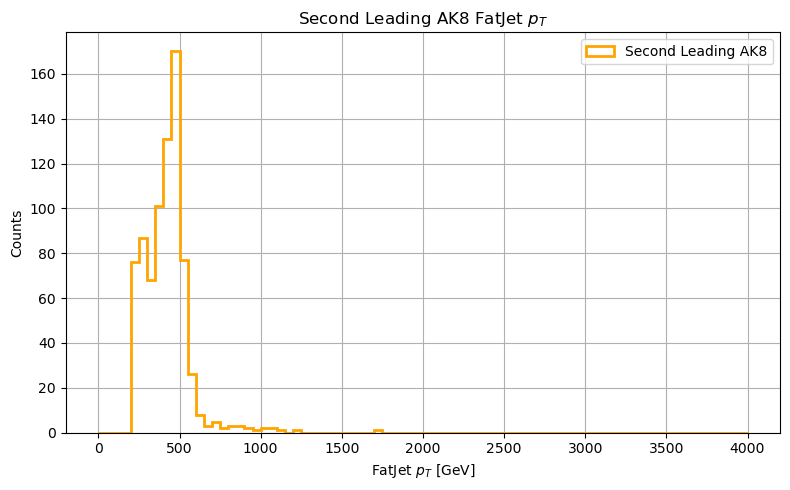

In [46]:
# Require events with at least two clean AK8 FatJets
AK8jets_2_mask = ak.num(clean_fatJets) >= 2
Wjets_2_candidates = clean_fatJets[AK8jets_2_mask]

# Second-leading jet: index 1
second_W_jet = Wjets_2_candidates[:, 1]
second_W_jet_pt = second_W_jet.pt

# Plot second-leading AK8 jet
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(second_W_jet_pt), bins=80, range=(0, 4000),
         histtype='step', linewidth=2, color='orange', label='Second Leading AK8')
plt.xlabel(r"FatJet $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Second Leading AK8 FatJet $p_T$")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

### Exploratory aside on the difference in kinemetic variables from jets in fully-hadronic and semi-leptonic W decay channels

### Goal: Compare the leading jet from the fuly hadronic vs semi-leptonic W decay channels using pt and eta

Steps:
1. Classify Events:
    - semi-leptonic mask: events with exactly 1 tight muon or electron and 1 AK8 jet
    - fully hadronic mask: events 0 tight leptons and 2 AK8 jets
2. Extract Leading Jets:
   - semi leptonic jets: FatJet in semi-leptonic events.
   - hadronic jets: Leading FatJet in hadronic events.
3. Plot Comparisons:
   - Overlay histograms of pt and eta for both types of events (maybe softdrop mass too).

In [47]:
# define tight lepton masks (already defined these earlier in the notebook)
n_tight_muons = ak.num(muons_tight)
n_tight_electrons = ak.num(electrons_tight)

# event masks
semi_leptonic_mask = (
    ((n_tight_muons == 1) & (n_tight_electrons == 0)) |
    ((n_tight_muons == 0) & (n_tight_electrons == 1))) & (ak.num(clean_fatJets) >= 1)

fully_hadronic_mask = (
    (n_tight_muons == 0) & (n_tight_electrons == 0) &
    (ak.num(clean_fatJets) >= 2))

In [48]:
# semi-leptonic W decay: select first FatJet in each semi-leptonic event
semi_leptonic_fatjets = clean_fatJets[semi_leptonic_mask]
semi_leptonic_leading_jet = semi_leptonic_fatjets[:, 0]

# fully hadronic W decay: select first FatJet in each hadronic event
fully_hadronic_fatjets = clean_fatJets[fully_hadronic_mask]
fully_hadronic_leading_jet = fully_hadronic_fatjets[:, 0]

# fully hadronic W decay: select second FatJet in each hadronic event
# Assumes there are at least two AK8 jets in the event
fully_hadronic_second_jet = fully_hadronic_fatjets[:, 1]

<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_338/4169022221.py:27: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Jet $\eta$ Distributions")


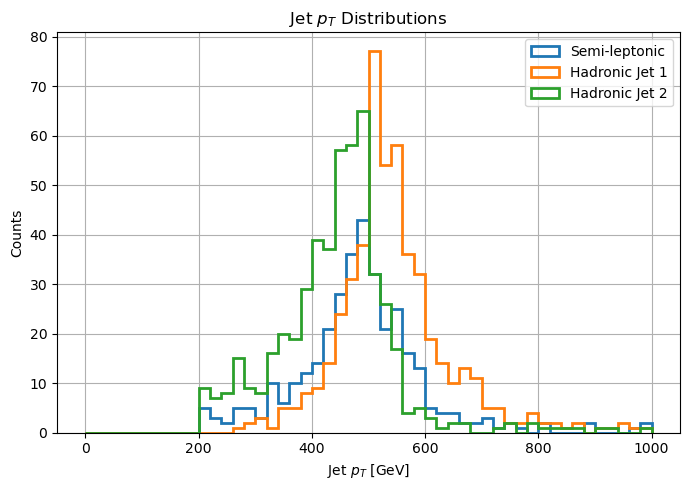

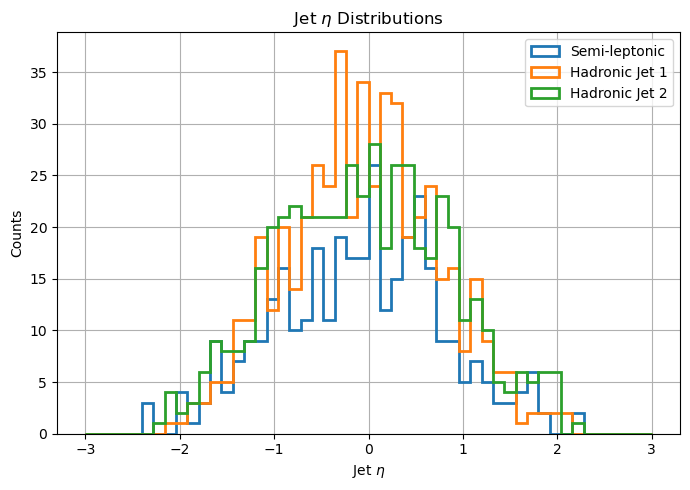

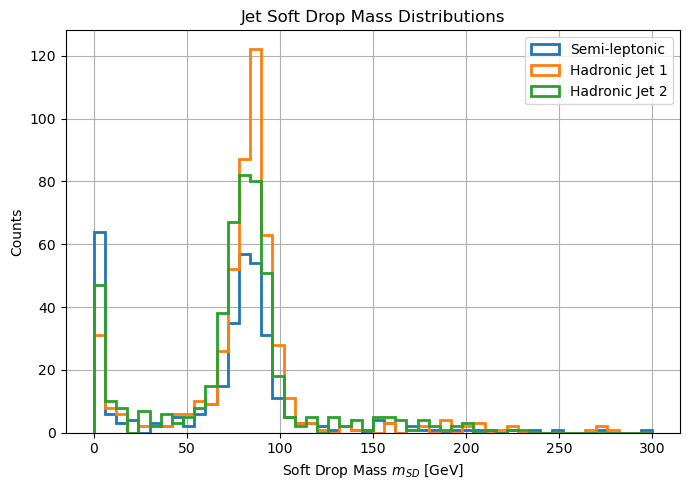

In [49]:
# -- Plot pT distribution --
plt.figure(figsize=(7, 5))
plt.hist(ak.to_numpy(semi_leptonic_leading_jet.pt), bins=50, range=(0, 1000),
         histtype='step', linewidth=2, label='Semi-leptonic')
plt.hist(ak.to_numpy(fully_hadronic_leading_jet.pt), bins=50, range=(0, 1000),
         histtype='step', linewidth=2, label='Hadronic Jet 1')
plt.hist(ak.to_numpy(fully_hadronic_second_jet.pt), bins=50, range=(0, 1000),
         histtype='step', linewidth=2, label='Hadronic Jet 2')
plt.xlabel(r"Jet $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Jet $p_T$ Distributions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -- Plot eta distribution --
plt.figure(figsize=(7, 5))
plt.hist(ak.to_numpy(semi_leptonic_leading_jet.eta), bins=50, range=(-3, 3),
         histtype='step', linewidth=2, label='Semi-leptonic')
plt.hist(ak.to_numpy(fully_hadronic_leading_jet.eta), bins=50, range=(-3, 3),
         histtype='step', linewidth=2, label='Hadronic Jet 1')
plt.hist(ak.to_numpy(fully_hadronic_second_jet.eta), bins=50, range=(-3, 3),
         histtype='step', linewidth=2, label='Hadronic Jet 2')
plt.xlabel(r"Jet $\eta$")
plt.ylabel("Counts")
plt.title("Jet $\eta$ Distributions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -- Plot soft drop mass distribution --
plt.figure(figsize=(7, 5))
plt.hist(ak.to_numpy(semi_leptonic_leading_jet.msoftdrop), bins=50, range=(0, 300),
         histtype='step', linewidth=2, label='Semi-leptonic')
plt.hist(ak.to_numpy(fully_hadronic_leading_jet.msoftdrop), bins=50, range=(0, 300),
         histtype='step', linewidth=2, label='Hadronic Jet 1')
plt.hist(ak.to_numpy(fully_hadronic_second_jet.msoftdrop), bins=50, range=(0, 300),
         histtype='step', linewidth=2, label='Hadronic Jet 2')
plt.xlabel(r"Soft Drop Mass $m_{SD}$ [GeV]")
plt.ylabel("Counts")
plt.title("Jet Soft Drop Mass Distributions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#normalize to jet unity, to overcome the diff in amount, divide by no of ee
# ratio plot, semi-leptonic / leading jet 1 and 2

#### msoftdrop? 
#### using FatJet.msoftdrop instead of raw mass because:
- It's more stable against pileup and soft radiation.
- It better captures the mass of boosted W bosons decaying into jets.

#### cos$\theta$ * calculation for all three jets

In [53]:
# # Compute W candidate vector (for hadronic decay) and boost vector
# vec_W_hadronic = vec_had1 + vec_had2
# boostvec = -vec_W_hadronic.to_beta3()

# # Boost the hadronic jets into W rest frame
# had1_boosted = vec_had1.boost(boostvec)
# had2_boosted = vec_had2.boost(boostvec)

# # Manually compute cos(theta*) = pz / |p| in the W rest frame
# def compute_costheta(vec):
#     p = np.sqrt(vec.px**2 + vec.py**2 + vec.pz**2)
#     return vec.pz / p

# costheta_star_had1 = compute_costheta(had1_boosted)
# costheta_star_had2 = compute_costheta(had2_boosted)

# # For semi-leptonic: no boost possible, use as-is (rough approximation)
# costheta_star_semi = compute_costheta(vec_semi)

# # --- Plot cos(theta*) distributions ---
# plt.figure(figsize=(7, 5))
# plt.hist(costheta_star_semi, bins=50, range=(-1, 1),
#          histtype='step', linewidth=2, label='Semi-leptonic')
# plt.hist(costheta_star_had1, bins=50, range=(-1, 1),
#          histtype='step', linewidth=2, label='Hadronic Jet 1')
# plt.hist(costheta_star_had2, bins=50, range=(-1, 1),
#          histtype='step', linewidth=2, label='Hadronic Jet 2')
# plt.xlabel(r"cos($\theta^*$)")
# plt.ylabel("Counts")
# plt.title(r"cos($\theta^*$) Distribution: Boosted Jet in W Rest Frame")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

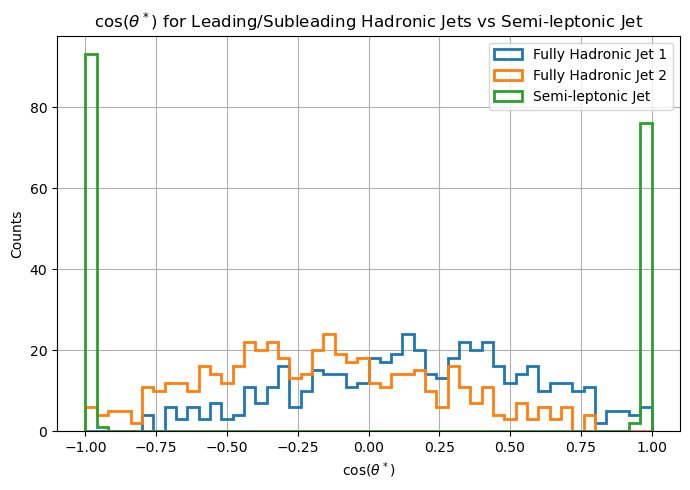

In [51]:
def calculate_cos_theta_star_david_style(jet1, jet2):
    """
    Compute cos(theta*) using helicity frame logic.
    - Form W = jet1 + jet2
    - Boost jet1 into W rest frame
    - Take angle between boosted jet1 and W direction in lab frame
    """
    vec1 = vector.array({
        "pt": ak.to_numpy(jet1.pt),
        "eta": ak.to_numpy(jet1.eta),
        "phi": ak.to_numpy(jet1.phi),
        "mass": ak.to_numpy(jet1.mass),
    })

    vec2 = vector.array({
        "pt": ak.to_numpy(jet2.pt),
        "eta": ak.to_numpy(jet2.eta),
        "phi": ak.to_numpy(jet2.phi),
        "mass": ak.to_numpy(jet2.mass),
    })

    cos_thetas = []
    for v1, v2 in zip(vec1, vec2):
        w_lab = v1 + v2
        if w_lab.mass < 1e-3 or w_lab.E <= 1e-6:
            continue

        beta3 = w_lab.to_beta3()
        v1_boosted = v1.boost_beta3(-beta3)

        w_dir = w_lab.to_beta3()
        v1_dir_rest = v1_boosted.to_beta3()

        if w_dir.mag < 1e-6 or v1_dir_rest.mag < 1e-6:
            continue

        cos_theta = v1_dir_rest.unit().dot(w_dir.unit())
        cos_thetas.append(cos_theta)

    return np.array(cos_thetas)

# Fully hadronic leading + second jet pair
costheta_star_fatjet1 = calculate_cos_theta_star_david_style(fully_hadronic_leading_jet, fully_hadronic_second_jet)

# Fully hadronic second + leading jet (same as above but switch roles, if you want to compare jet2 as probe)
costheta_star_fatjet2 = calculate_cos_theta_star_david_style(fully_hadronic_second_jet, fully_hadronic_leading_jet)

# Semi-leptonic jet paired with a zero jet
dummy_zeros = fully_hadronic_leading_jet * 0
costheta_star_semilep = calculate_cos_theta_star_david_style(semi_leptonic_leading_jet, dummy_zeros)

plt.figure(figsize=(7, 5))

plt.hist(costheta_star_fatjet1, bins=50, range=(-1, 1), histtype='step', linewidth=2, label='Fully Hadronic Jet 1')
plt.hist(costheta_star_fatjet2, bins=50, range=(-1, 1), histtype='step', linewidth=2, label='Fully Hadronic Jet 2')
plt.hist(costheta_star_semilep, bins=50, range=(-1, 1), histtype='step', linewidth=2, label='Semi-leptonic Jet')

plt.xlabel(r"$\cos(\theta^*)$")
plt.ylabel("Counts")
plt.title(r"cos($\theta^*$) for Leading/Subleading Hadronic Jets vs Semi-leptonic Jet")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Now that you are familiar with the physics behind what we are doing we move to the ML part


### TASK 9: 

To train the neural network it is useful to first select the interesting events (as we have done above). But now we need to save the events and variables in a more useful file format called h5. Check the example below to see how to add variables to be saved

In [26]:
# basic h5 creation
import pandas as pd
# Convert awkward array to numpy array (flat)
leading_W_jet_pt_np = ak.to_numpy(leading_W_jet_pt)
leading_W_jet_eta_np = ak.to_numpy(leading_W_jet.eta)
# Optional — wrap in a DataFrame for easy labeling
df_leading_W_jet_pt = pd.DataFrame({'leading_W_jet_pt': leading_W_jet_pt_np, 'leading_W_jet_eta': leading_W_jet_eta_np})


In [27]:
df_leading_W_jet_pt.to_hdf('leading_W_jet_pt.h5', key='df', mode='w')


In [28]:
# run this command to see if the file has been creatd
import os
os.listdir('.')

['leading_W_jet_pt.h5',
 'resonancesTest_plotVariables.ipynb',
 '.gitignore',
 'resonancesTest_selections_h5.ipynb',
 'RSGravToWWToWlepWhad_M-1200.root',
 '.git',
 '.ipynb_checkpoints',
 'BulkGravitonToWW_M-1000.root',
 'README.md']

In [21]:
# now read the file to see if it looks ok
pd.read_hdf('leading_W_jet_pt.h5')

,leading_W_jet_pt,leading_W_jet_eta
0,348.75,0.429260
1,468.25,0.294067
2,497.50,-0.151031
3,606.50,0.087845
4,490.75,-0.167938
...,...,...
970,688.50,-0.026592
971,630.50,-0.421326
972,532.00,-1.101562
973,489.25,-0.752319


### TASK 10: 

Now we need to add variables that will be useful for our polarization tagger. So cos theta is one of them for sure! You can recall the calculations from the other notebook. 

Are there more variables we want to add? If nothing else comes up we can 
1) add the full stats!!
2) move to the ML part! 

In [37]:
# Ensure FatJet vector is defined
fatjet_vec = vector.array({
    "pt": leading_W_jet.pt,
    "eta": leading_W_jet.eta,
    "phi": leading_W_jet.phi,
    "mass": leading_W_jet.mass,
})

# Calculate cos(theta) = pz / |p| using Cartesian components
cos_theta = fatjet_vec.pz / fatjet_vec.p

# Convert to flat numpy
cos_theta_np = ak.to_numpy(cos_theta)

In [38]:
# Extract variables from leading W candidate (FatJet)
df_features = pd.DataFrame({
    'pt': ak.to_numpy(leading_W_jet.pt),
    'eta': ak.to_numpy(leading_W_jet.eta),
    'mass': ak.to_numpy(leading_W_jet.mass),
    'msoftdrop': ak.to_numpy(leading_W_jet.msoftdrop),
    'cos_theta': cos_theta_np,
})

# Save to h5 file
df_features.to_hdf('leading_W_features.h5', key='df', mode='w')

# Confirm it was saved
import os
print(os.listdir('.'))

['leading_W_jet_pt.h5', 'resonancesTest_plotVariables.ipynb', '.gitignore', 'resonancesTest_selections_h5.ipynb', 'leading_W_features.h5', 'RSGravToWWToWlepWhad_M-1200.root', '.git', '.ipynb_checkpoints', 'BulkGravitonToWW_M-1000.root', 'README.md']


In [39]:
# Load and preview
pd.read_hdf('leading_W_features.h5').head()

,pt,eta,mass,msoftdrop,cos_theta
0,348.75,0.429260,41.78125,0.036560,0.404703
1,468.25,0.294067,104.68750,98.812500,0.285874
2,497.50,-0.151031,20.87500,0.115173,-0.149894
3,606.50,0.087845,106.68750,88.062500,0.087620
4,490.75,-0.167938,87.18750,84.187500,-0.166377
